In [1]:
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import os

df = pd.read_csv('../data/transactions_cleaned.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['is_failed'] = (df['status'] == 'Failed').astype(int)

What is the failure count by hour of day.During which part of the day , do we see the spike?

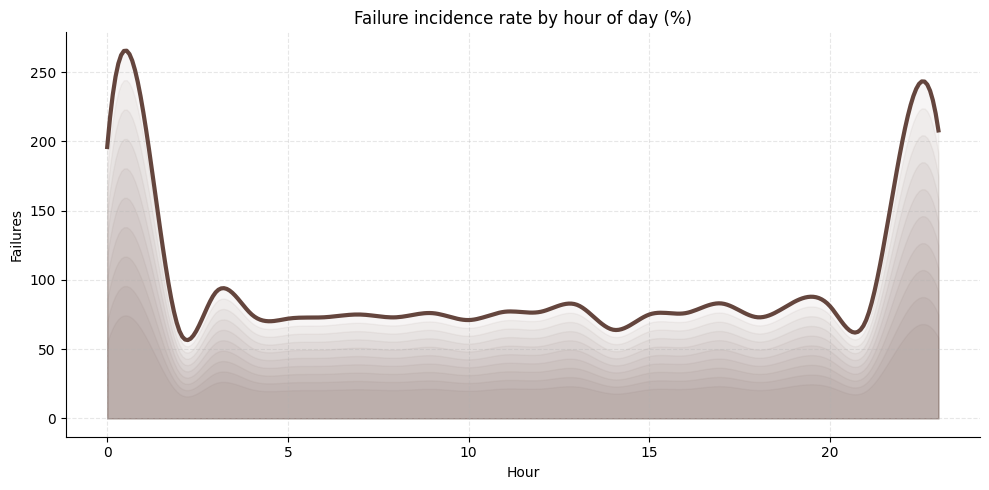

In [2]:
hours_failed = df[df['is_failed']==1].groupby('hour').size()
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Smooth data
x = hours_failed.index
y = hours_failed.values

x_new = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_new)

plt.figure(figsize=(10,5))

# Line
plt.plot(x_new, y_smooth, color='#64453d', linewidth=3)

# Simple gradient effect (layered fill)
for i in range(10):
    plt.fill_between(
        x_new,
        y_smooth * (1 - i*0.08),
        color='#64453d',
        alpha=0.05
    )

# Styling
plt.title('Failure incidence rate by hour of day (%)')
plt.xlabel('Hour')
plt.ylabel('Failures')

plt.grid(True, linestyle='--', alpha=0.3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Failure rates are highest during late night (1 AM) and late evening (10–11 PM).The most stable period is early morning (3–6 AM) and daytime hours.There is a consistent pattern of low daytime failures and high night-time spikes. Overall, time of day strongly influences transaction reliability.

what is the failure count by day of week?

In [3]:
day_failures = df[df['is_failed']==1].groupby('day_of_week').size()
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['day_of_week'] = df['timestamp'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_failures = day_failures.reindex(days_order)


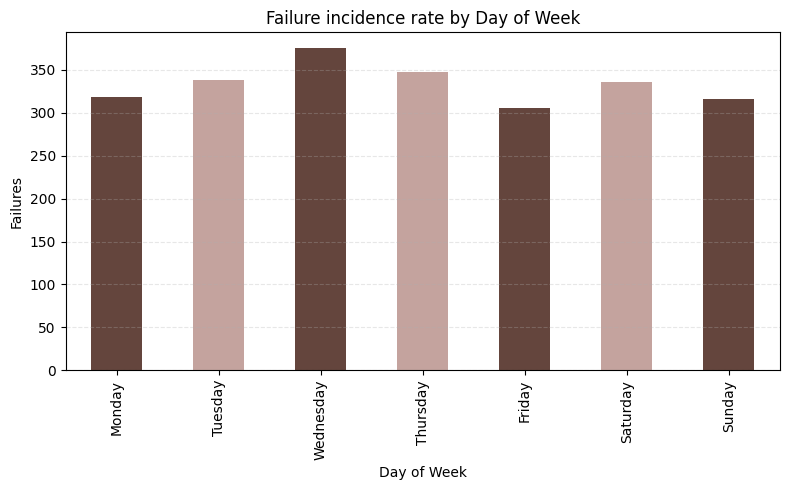

In [4]:
plt.figure(figsize=(8,5))

day_failures.plot(kind='bar', color=['#64453d', '#c4a39e'])

plt.title('Failure incidence rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Failures')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Failures are highest during mid-week, especially Wednesday and Thursday.Friday shows the lowest failure count, indicating better system stability.Weekends have moderate but consistent failure levels.Overall, failures peak during high workload weekdays.

what is the failure count by day of the month?

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['day_of_month']=df['timestamp'].dt.day

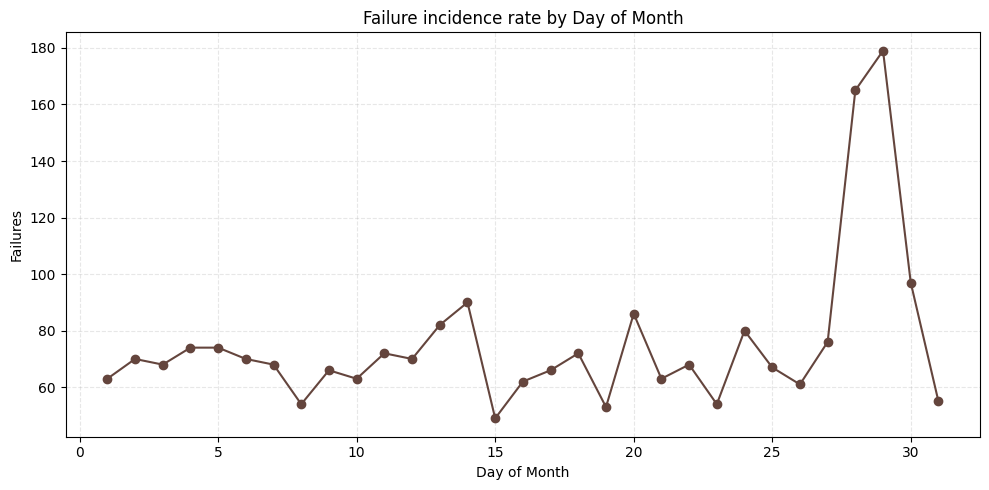

In [6]:
day_of_month_failures = df[df['is_failed']==1].groupby('day_of_month').size()
plt.figure(figsize=(10,5))
day_of_month_failures.plot(kind='line',marker = 'o',color='#64453d')
plt.title('Failure incidence rate by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Failures')
plt.grid(True, linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()

Failure rates remain stable for most of the month, with a sharp spike on Day 28–29.The lowest failure activity occurs around mid-month (Day 15).End-of-month shows a sudden surge in failures, likely due to increased transaction load.Overall, failures are influenced by monthly transaction cycles.

calculate failure_rate_by_hour

In [7]:
failure_rate_by_month = df.groupby("day_of_month")['is_failed'].mean()*100
print(failure_rate_by_month)
print(max(df['day_of_month']), failure_rate_by_month.max())

day_of_month
1     19.207317
2     21.806854
3     20.298507
4     22.023810
5     20.441989
6     19.774011
7     21.383648
8     17.197452
9     19.298246
10    19.325153
11    20.809249
12    20.588235
13    23.361823
14    25.714286
15    15.857605
16    17.714286
17    22.916667
18    21.621622
19    16.459627
20    27.215190
21    20.063694
22    23.943662
23    16.265060
24    22.988506
25    21.474359
26    17.994100
27    21.169916
28    46.610169
29    47.606383
30    42.358079
31    49.107143
Name: is_failed, dtype: float64
31 49.107142857142854


find 3 worst and 3 best hours.

In [8]:
worst_hours = failure_rate_by_month.sort_values(ascending=False).head(5)
best_hours = failure_rate_by_month.sort_values(ascending=True).head(5)
print("Worst Hours for Failures:", worst_hours)
print()
print("Best Hours for Failures:", best_hours)

Worst Hours for Failures: day_of_month
31    49.107143
29    47.606383
28    46.610169
30    42.358079
20    27.215190
Name: is_failed, dtype: float64

Best Hours for Failures: day_of_month
15    15.857605
23    16.265060
19    16.459627
8     17.197452
16    17.714286
Name: is_failed, dtype: float64
